**Latar Belakang**

Sampah laut merupakan salah satu masalah yang dapat mengganggu kelestarian ekosistem laut. Sampah seperti plastik, botol, dan berbagai jenis limbah lainnya dapat mencemari perairan serta membahayakan kehidupan biota laut. Karena itu, diperlukan upaya untuk mengetahui dan mengelompokkan tingkat pencemaran sampah laut agar penanganannya dapat dilakukan dengan lebih tepat.

**Tujuan Projek**

1. Mengidentifikasi kondisi pencemaran sampah laut berdasarkan data yang tersedia.
2. Mengklasifikasikan tingkat pencemaran menjadi kategori rendah, sedang, dan tinggi.
3. Menerapkan metode Random Forest untuk melakukan klasifikasi.
4. Membandingkan hasil Random Forest dengan Logistic Regression.
5. Mengetahui fitur yang paling banyak berkontribusi terhadap hasil klasifikasi.

**Rumusan Masalah**

1. Bagaimana cara menentukan tingkat pencemaran sampah laut berdasarkan data yang tersedia?
2. Bagaimana cara mengelompokkan tingkat pencemaran menjadi rendah, sedang, dan tinggi?
3. Bagaimana Random Forest dapat digunakan untuk mengklasifikasikan tingkat pencemaran sampah laut?

**TAHAP 1 — Membaca Dataset dan Data Understanding**

Penjelasan:

Pada tahap ini dataset dibaca dan diperiksa untuk mengetahui jumlah data, jumlah variabel, serta melihat beberapa data awal yang akan digunakan dalam proses klasifikasi.

In [ ]:
import pandas as pd
import os

# Nama file dataset
file_name = 'Plastic_Waste_Around_the_World_Rapih.csv'

# Mengecek apakah file tersedia
if os.path.exists(file_name):
    df = pd.read_csv(file_name)

    print("Sukses! Dataset berhasil dimuat.")

    # Menampilkan jumlah baris dan kolom
    print("\n--- Data Understanding ---")
    print(f"Total Jumlah Baris: {df.shape[0]}")
    print(f"Total Jumlah Kolom: {df.shape[1]}")

    # Menampilkan 5 data pertama
    print("\n--- 5 Baris Pertama Dataset ---")
    display(df.head())

    # Menampilkan informasi dataset
    print("\n--- Informasi Dataset ---")
    df.info()

    # Mengecek data kosong
    print("\n--- Data Kosong ---")
    print(df.isnull().sum())

    # Mengecek data duplikat
    print("\n--- Data Duplikat ---")
    print(df.duplicated().sum())

else:
    print(f"File '{file_name}' tidak ditemukan!")
    print("Pastikan dataset sudah di-upload ke Google Colab.")

Sukses! Dataset berhasil dimuat.

--- Data Understanding ---
Total Jumlah Baris: 165
Total Jumlah Kolom: 6

--- 5 Baris Pertama Dataset ---


,Country,Total_Plastic_Waste_MT,Main_Sources,Recycling_Rate,Per_Capita_Waste_KG,Coastal_Waste_Risk
0,China,59.08,Packaging_Industrial,29.8,41.2,High
1,United States,42.02,Packaging_Consumer,32.1,127.5,Medium
2,India,26.33,Consumer_Goods,11.5,19.3,High
3,Japan,7.99,Packaging_Electronics,84.8,63.2,Medium
4,Germany,6.28,Automotive_Packaging,56.1,75.6,Low



--- Informasi Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 165 entries, 0 to 164
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Country                 165 non-null    object 
 1   Total_Plastic_Waste_MT  165 non-null    float64
 2   Main_Sources            165 non-null    object 
 3   Recycling_Rate          165 non-null    float64
 4   Per_Capita_Waste_KG     165 non-null    float64
 5   Coastal_Waste_Risk      165 non-null    object 
dtypes: float64(3), object(3)
memory usage: 7.9+ KB

--- Data Kosong ---
Country                   0
Total_Plastic_Waste_MT    0
Main_Sources              0
Recycling_Rate            0
Per_Capita_Waste_KG       0
Coastal_Waste_Risk        0
dtype: int64

--- Data Duplikat ---
0


**TAHAP 2 — Data Cleaning dan Preprocessing**

Penjelasan:

Pada tahap ini kategori Very_High dihapus agar data yang digunakan hanya memiliki tiga kategori risiko, yaitu Low, Medium, dan High. Setelah itu data dipersiapkan untuk digunakan dalam proses Machine Learning.

In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Menghapus kategori Very_High
df = df[df["Coastal_Waste_Risk"] != "Very_High"].copy()

# Membuat target
df["Target"] = df["Coastal_Waste_Risk"]

print("Jumlah data setelah menghapus Very_High:")
print(df.shape[0])

print("\nDistribusi kategori:")
print(df["Target"].value_counts())

Jumlah data setelah menghapus Very_High:
161

Distribusi kategori:
Target
High      74
Low       54
Medium    33
Name: count, dtype: int64


**TAHAP 3 — Menentukan Fitur dan Target**

Penjelasan:

Pada tahap ini ditentukan fitur yang digunakan sebagai input model dan target yang akan diprediksi. Fitur yang digunakan terdiri dari jumlah sampah plastik, sumber sampah, tingkat daur ulang, dan sampah per kapita.

In [ ]:
# Menentukan fitur angka
fitur_angka = [
    "Total_Plastic_Waste_MT",
    "Recycling_Rate",
    "Per_Capita_Waste_KG"
]

# Menentukan fitur kategori
fitur_kategori = [
    "Main_Sources"
]

# Menentukan X dan y
X = df[fitur_angka + fitur_kategori]
y = df["Target"]

print("Fitur yang digunakan:")
print(X.columns.tolist())

print("\nTarget:")
print("Low, Medium, High")

Fitur yang digunakan:
['Total_Plastic_Waste_MT', 'Recycling_Rate', 'Per_Capita_Waste_KG', 'Main_Sources']

Target:
Low, Medium, High


**TAHAP 4 — Membagi Data Training dan Testing**

Penjelasan:

Pada tahap ini data dibagi menjadi data training untuk melatih model dan data testing untuk menguji kemampuan model dalam melakukan klasifikasi.

In [ ]:
from sklearn.model_selection import train_test_split

# Membagi data menjadi 80% training dan 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Jumlah Data Training: {X_train.shape[0]}")
print(f"Jumlah Data Testing: {X_test.shape[0]}")

print("\nDistribusi Data Training:")
print(y_train.value_counts())

print("\nDistribusi Data Testing:")
print(y_test.value_counts())

Jumlah Data Training: 128
Jumlah Data Testing: 33

Distribusi Data Training:
Target
High      59
Low       43
Medium    26
Name: count, dtype: int64

Distribusi Data Testing:
Target
High      15
Low       11
Medium     7
Name: count, dtype: int64


**TAHAP 5 — Preprocessing Data**

Penjelasan:

Pada tahap ini data kategori diubah menjadi bentuk angka menggunakan One Hot Encoding agar dapat diproses oleh model Machine Learning.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Menentukan kembali fitur kategori untuk menghindari NameError jika sel sebelumnya belum dieksekusi
fitur_kategori = ["Main_Sources"]
fitur_angka = ["Total_Plastic_Waste_MT", "Recycling_Rate", "Per_Capita_Waste_KG"]

# Membuat preprocessing untuk data
preprocessing = ColumnTransformer([
    (
        "kategori",
        OneHotEncoder(handle_unknown="ignore"),
        fitur_kategori
    )
], remainder="passthrough")

# Mengubah data training dan testing
X_train_processed = preprocessing.fit_transform(X_train)
X_test_processed = preprocessing.transform(X_test)

print("Preprocessing data berhasil dilakukan.")

Preprocessing data berhasil dilakukan.


**TAHAP 6 — Pemodelan Random Forest**

Penjelasan:

Pada tahap ini Random Forest digunakan sebagai model utama untuk mempelajari pola data training dan memprediksi kategori risiko pada data testing.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

# Membuat model Random Forest
model_rf = Pipeline([
    ("preprocessing", preprocessing),
    (
        "model",
        RandomForestClassifier(
            n_estimators=100,
            random_state=42
        )
    )
])

# Melatih model
model_rf.fit(X_train, y_train)

# Melakukan prediksi
prediksi_rf = model_rf.predict(X_test)

print("Model Random Forest berhasil dilatih.")

Model Random Forest berhasil dilatih.


**TAHAP 7 — Pemodelan Logistic Regression**

Penjelasan:

Logistic Regression digunakan sebagai model pembanding untuk melihat apakah hasil klasifikasinya lebih baik atau lebih rendah dibandingkan Random Forest.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Preprocessing untuk Logistic Regression
preprocessing_lr = ColumnTransformer([
    (
        "angka",
        StandardScaler(),
        fitur_angka
    ),
    (
        "kategori",
        OneHotEncoder(handle_unknown="ignore"),
        fitur_kategori
    )
])

# Membuat model Logistic Regression
model_lr = Pipeline([
    ("preprocessing", preprocessing_lr),
    (
        "model",
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    )
])

# Melatih model
model_lr.fit(X_train, y_train)

# Melakukan prediksi
prediksi_lr = model_lr.predict(X_test)

print("Model Logistic Regression berhasil dilatih.")

Model Logistic Regression berhasil dilatih.


**TAHAP 8 — Evaluasi Model**

Penjelasan:

Pada tahap ini performa Random Forest dan Logistic Regression dibandingkan menggunakan accuracy, precision, recall, dan F1-score.

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

# Evaluasi Random Forest
print("=== RANDOM FOREST ===")

print("Akurasi:")
print(accuracy_score(y_test, prediksi_rf))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        prediksi_rf,
        zero_division=0
    )
)


# Evaluasi Logistic Regression
print("\n=== LOGISTIC REGRESSION ===")

print("Akurasi:")
print(accuracy_score(y_test, prediksi_lr))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        prediksi_lr,
        zero_division=0
    )
)

=== RANDOM FOREST ===
Akurasi:
0.6666666666666666

Classification Report:
              precision    recall  f1-score   support

        High       0.76      0.87      0.81        15
         Low       0.56      0.45      0.50        11
      Medium       0.57      0.57      0.57         7

    accuracy                           0.67        33
   macro avg       0.63      0.63      0.63        33
weighted avg       0.65      0.67      0.66        33


=== LOGISTIC REGRESSION ===
Akurasi:
0.5454545454545454

Classification Report:
              precision    recall  f1-score   support

        High       0.56      0.93      0.70        15
         Low       0.50      0.09      0.15        11
      Medium       0.50      0.43      0.46         7

    accuracy                           0.55        33
   macro avg       0.52      0.48      0.44        33
weighted avg       0.53      0.55      0.47        33



**TAHAP 9 — Confusion Matrix**

Penjelasan:

Confusion Matrix digunakan untuk melihat jumlah prediksi yang benar dan salah pada masing-masing kategori Low, Medium, dan High.

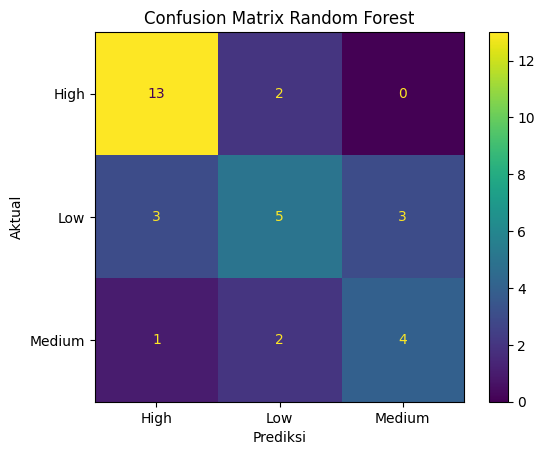

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Membuat confusion matrix Random Forest
ConfusionMatrixDisplay.from_predictions(
    y_test,
    prediksi_rf
)

plt.title("Confusion Matrix Random Forest")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.show()

# **TAHAP 10 — Feature Importance**

Penjelasan:

Pada tahap ini dilihat fitur yang paling banyak berkontribusi terhadap prediksi Random Forest.

In [ ]:
import pandas as pd

# Mengambil nama fitur setelah preprocessing
nama_fitur_kategori = preprocessing.named_transformers_[
    "kategori"
].get_feature_names_out(fitur_kategori)

nama_fitur = list(nama_fitur_kategori) + fitur_angka

# Mengambil nilai feature importance
importance = model_rf.named_steps["model"].feature_importances_

feature_importance = pd.DataFrame({
    "Fitur": nama_fitur,
    "Importance": importance
}).sort_values(
    by="Importance",
    ascending=False
)

display(feature_importance)

,Fitur,Importance
8,Total_Plastic_Waste_MT,0.322526
9,Recycling_Rate,0.314036
10,Per_Capita_Waste_KG,0.255627
1,Main_Sources_Consumer_Packaging,0.051662
4,Main_Sources_Industrial_Packaging,0.020797
5,Main_Sources_Packaging_Consumer,0.010763
3,Main_Sources_Industrial_Consumer,0.008052
7,Main_Sources_Packaging_Industrial,0.005956
2,Main_Sources_Electronics_Packaging,0.005406
6,Main_Sources_Packaging_Electronics,0.003920


**Grafik**:

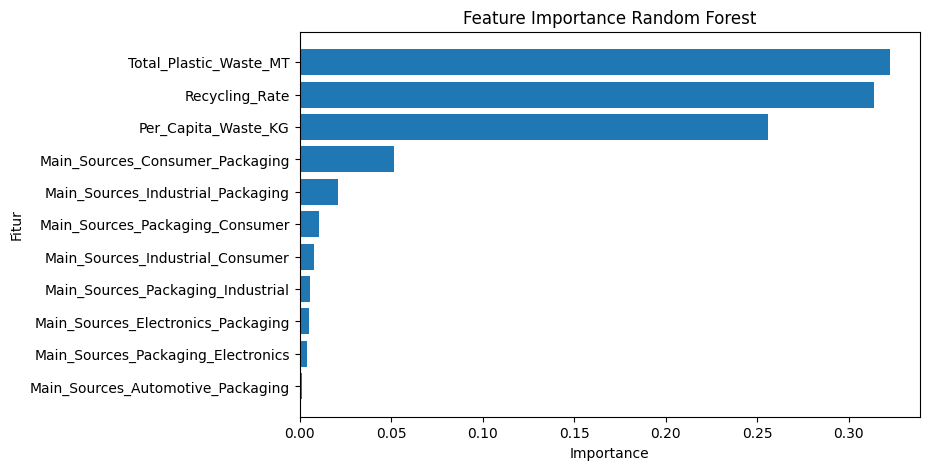

In [ ]:
plt.figure(figsize=(8, 5))

plt.barh(
    feature_importance["Fitur"][::-1],
    feature_importance["Importance"][::-1]
)

plt.title("Feature Importance Random Forest")
plt.xlabel("Importance")
plt.ylabel("Fitur")

plt.show()

In [ ]:
print("=" * 60)
print("KESIMPULAN DAN REKOMENDASI")
print("=" * 60)

print("""
1. Dataset berhasil digunakan untuk mengklasifikasikan
   tingkat risiko sampah plastik menjadi tiga kategori,
   yaitu Low, Medium, dan High.

2. Random Forest dan Logistic Regression berhasil
   diterapkan untuk melakukan klasifikasi.

3. Hasil evaluasi digunakan untuk mengetahui model
   yang memberikan performa lebih baik.

4. Feature Importance digunakan untuk mengetahui
   fitur yang paling banyak berkontribusi terhadap
   prediksi model.

5. Hasil klasifikasi dapat menjadi informasi tambahan
   dalam memahami kondisi pencemaran sampah di kawasan
   pesisir.
""")

print("=" * 60)

KESIMPULAN DAN REKOMENDASI

1. Dataset berhasil digunakan untuk mengklasifikasikan
   tingkat risiko sampah plastik menjadi tiga kategori,
   yaitu Low, Medium, dan High.

2. Random Forest dan Logistic Regression berhasil
   diterapkan untuk melakukan klasifikasi.

3. Hasil evaluasi digunakan untuk mengetahui model
   yang memberikan performa lebih baik.

4. Feature Importance digunakan untuk mengetahui
   fitur yang paling banyak berkontribusi terhadap
   prediksi model.

5. Hasil klasifikasi dapat menjadi informasi tambahan
   dalam memahami kondisi pencemaran sampah di kawasan
   pesisir.

